# **Section 1: Khám phá (Exploration)**

In [12]:
import pandas as pd
import os

base_path = os.getcwd()
file_path = os.path.join(base_path, 'dataset', 'salary_survey_raw.csv')

df = pd.read_csv(file_path)

# 1. Kiểm tra kích thước 
print(f"Số lượng dòng: {df.shape[0]}")
print(f"Số lượng cột: {df.shape[1]}")

# 2. Xem 5 dòng đầu tiên 
display(df.head())

# 3. Kiểm tra kiểu dữ liệu và giá trị non-null
df.info()
df.describe(include='all')


Số lượng dòng: 2800
Số lượng cột: 17


,timestamp,how_old_are_you,industry,job_title,additional_context_on_job_title,annual_salary,additional_monetary_comp,currency,income_context,country,us_state,city,years_of_experience_in_field,years_of_experience_overall,highest_level_of_education,gender,race
0,04/12/2021 16:11:47,45-54,Legal,Legal Counsel,NaN,"56,894",NaN,USD,NaN,NaN,NaN,Boston,21 - 30 years,21 - 30 years,College degree,Man,Black or African American
1,04/25/2021 09:28:06,25-34,Finance,Investment Analyst,NaN,"144,543","$9,839",USD,NaN,United States,Washington,NaN,8 - 10 years,8 - 10 years,College degree,Man,Multiracial
2,04/15/2021,25-34,Nonprofit,Grant Writer,NaN,"52,304.00",NaN,AUD,NaN,United States,Washington,NaN,21 - 30 years,21 - 30 years,PhD,Woman,NaN
3,04/21/2021 03:36:47,55-64,Real Estate,Real Estate Manager,NaN,"51,765",18454,AUD,NaN,United States,NaN,Los Angeles,2 - 4 years,2 - 4 years,Master's degree,Male,NaN
4,2021-04-26 03:04,35-44,Nursing,Charge Nurse,Senior level,"133,218","8,424",USD,NaN,UK,NaN,NaN,11 - 20 years,11 - 20 years,College degree,Woman,NaN


<class 'pandas.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   timestamp                        2800 non-null   str  
 1   how_old_are_you                  2800 non-null   str  
 2   industry                         2800 non-null   str  
 3   job_title                        2800 non-null   str  
 4   additional_context_on_job_title  1831 non-null   str  
 5   annual_salary                    2409 non-null   str  
 6   additional_monetary_comp         1262 non-null   str  
 7   currency                         2800 non-null   str  
 8   income_context                   531 non-null    str  
 9   country                          2685 non-null   str  
 10  us_state                         987 non-null    str  
 11  city                             1238 non-null   str  
 12  years_of_experience_in_field     2800 non-null   str  
 13 

,timestamp,how_old_are_you,industry,job_title,additional_context_on_job_title,annual_salary,additional_monetary_comp,currency,income_context,country,us_state,city,years_of_experience_in_field,years_of_experience_overall,highest_level_of_education,gender,race
count,2800,2800,2800,2800,1831,2409,1262,2800,531,2685,987,1238,2800,2800,2800,2731,2034
unique,2058,7,24,185,9,2297,1025,8,4,17,9,9,7,7,6,8,6
top,04/23/2021,25-34,Tech/Software,PA,Part-time equivalent,"20,160",0,USD,gross,United States,Texas,Austin,11 - 20 years,11 - 20 years,College degree,Woman,Black or African American
freq,51,1001,292,31,220,5,61,1591,142,849,125,148,668,668,1112,871,367



###  Quan sát về quy mô và độ đầy đủ
* **Kích thước**: Dataset có **2800 hàng** và **17 cột**.
* **Độ đầy đủ**: Chỉ có 8 cột là đầy đủ 100% dữ liệu. Các cột quan trọng như `annual_salary` và `additional_monetary_comp` có tỉ lệ null rất cao.
* **Phân tích**: Việc thiếu hụt dữ liệu ở cột lương có thể thuộc loại **MNAR (Missing Not At Random)** - người có thu nhập quá thấp hoặc quá cao thường ngại khai báo, điều này có thể gây bias nếu ta xử lý không khéo.

###  Vấn đề về Kiểu dữ liệu (Dtype)
* Qua hàm `.info()`, cột `annual_salary` đang bị lưu ở dạng **object** (chuỗi) thay vì numeric (số).
* Mặc dù các cột hiển thị là object, thực tế đây là kiểu dữ liệu chuỗi (string) trong Pandas. Tuy nhiên, với các cột định lượng như annual_salary, việc để ở kiểu object khiến ta không thể tính toán thống kê. Do đó, bước tiếp theo bắt buộc phải là loại bỏ ký tự đặc biệt và ép kiểu về float64 để dữ liệu có thể 'tính toán' được. 
* **Ví dụ : " 52,304.00" , "51,765" , " $9,839" đang là String nên khó có thể tính toán.**
* **Hệ quả**: Không thể thực hiện các phép toán thống kê như Mean, Median hay vẽ biểu đồ định lượng. 
* **Hướng xử lý**: Cần thực hiện loại bỏ các ký tự đặc biệt ($, dấu phẩy) và ép lại kiểu dữ liệu về `float64`.



# **TUẦN 1 — MISSING VALUES, DUPLICATES & DATA TYPES**

In [13]:
def missing_report(df):
    # 1. Tính tổng số lượng null trên mỗi cột 
    miss = df.isnull().sum()
    
    # 2. Tính tỉ lệ phần trăm null
    pct = (miss / len(df) * 100).round(2)
    report = pd.DataFrame({'Missing Count': miss, 'Percentage (%)': pct})
    return report.query('`Missing Count` > 0').sort_values('Percentage (%)', ascending=False)


display(missing_report(df))

,Missing Count,Percentage (%)
income_context,2269,81.04
us_state,1813,64.75
city,1562,55.79
additional_monetary_comp,1538,54.93
additional_context_on_job_title,969,34.61
race,766,27.36
annual_salary,391,13.96
country,115,4.11
gender,69,2.46



###  Decision Log 


| Nhóm cột | Tên cột | Loại Null | Chiến lược | Lý do (Logic) |
| :--- | :--- | :--- | :--- | :--- |
| **Định lượng** | `annual_salary` | **MNAR** | `fillna(median)` | Lương thường phân phối lệch phải; người thu nhập cực thấp/cao có xu hướng ngại khai. Median giúp tránh nhiễu do Outliers tốt hơn Mean. |
| **Định lượng** | `additional_monetary_comp` | **MAR** | `fillna(0)` | **Ghi nhận ngầm**: Trong khảo sát lương, không điền thường đồng nghĩa với việc không phát sinh thưởng hoặc hoa hồng. |
| **Vị trí** | `country`, `city` | **MCAR** | `fillna('Unknown')` | Lỗi nhập liệu ngẫu nhiên hoặc người dùng muốn bảo mật vị trí. Tỉ lệ thấp, giữ lại để bảo toàn các thông tin khác trong hàng. |
| **Vị trí** | `us_state` | **Logic/MAR** | `fillna('Non-US')` | **Dữ liệu phụ thuộc**: Chỉ người làm việc tại Mỹ mới điền cột này. Null là hợp lệ đối với các ứng viên quốc tế. |
| **Nhân khẩu** | `gender`, `race` | **MCAR** | `dropna()` | Tỉ lệ thiếu hụt rất nhỏ (<3%). Xóa các hàng này để đảm bảo độ chính xác tuyệt đối cho các biểu đồ phân tích nhân khẩu học. |
| **Key Fields** | `job_title`, `industry` | **MCAR** | `dropna()` | Đây là các cột biến độc lập chính. Nếu thiếu, bản ghi không còn giá trị để phân tích mối tương quan giữa nghề nghiệp và tiền lương. |
| **Ghi chú** | `income_context`, `job_context` | **MAR** | `fillna('None')` | Thông tin bổ sung không bắt buộc. Việc điền 'None' giúp đồng bộ kiểu dữ liệu chuỗi (string) để tránh lỗi xử lý ở các bước sau. |

###  Phân tích 

1. **Về các cột Key Fields**: Mục tiêu của bài toán là phân tích lương theo ngành và chức danh. Một bản ghi có lương nhưng không biết làm nghề gì hay ở ngành nào thì hoàn toàn vô dụng cho việc thống kê, do đó việc loại bỏ (`dropna`) là cần thiết.
2. **Về tính Logic của địa lý**: Cột `us_state` trống không phải là lỗi mà là một sự thật khách quan (người làm ngoài Mỹ). Việc gán nhãn 'Non-US' thay vì 'Unknown' thể hiện sự hiểu biết về bối cảnh dữ liệu.
3. **Về dữ liệu định tính (Context)**: Tỉ lệ null lên đến 81% ở các cột ghi chú là hoàn toàn bình thường trong các khảo sát mở. Chúng ta giữ lại bằng cách gán nhãn 'None' để không làm mất đi các dữ liệu định lượng quý giá ở cùng hàng đó.

In [14]:
# 1. Tạo bản sao để so sánh trước/sau 
df_clean = df.copy()

# --- CHIẾN LƯỢC 1: FILLNA (IMPUTATION) & ÉP KIỂU ---

# Xử lý Lương: Xóa ký tự đặc biệt, ép kiểu float để tính toán
df_clean['annual_salary'] = pd.to_numeric(
    df_clean['annual_salary'].astype(str).str.replace(r'[^\d.]', '', regex=True), 
    errors='coerce'
)

# LÝ DO: annual_salary là MNAR, dùng median theo industry để tránh bias do outliers
# (Lưu ý: Nếu industry bị null, ta sẽ fill median tổng để đảm bảo không còn null)
df_clean['annual_salary'] = df_clean.groupby('industry')['annual_salary'].transform(
    lambda x: x.fillna(x.median())
).fillna(df_clean['annual_salary'].median())

# Xử lý Thưởng: "Ghi nhận ngầm" MAR => Điền 0
df_clean['additional_monetary_comp'] = pd.to_numeric(
    df_clean['additional_monetary_comp'].astype(str).str.replace(r'[^\d.]', '', regex=True), 
    errors='coerce'
).fillna(0)

# Xử lý các cột Vị trí & Ghi chú (Constant Fillna)
# LÝ DO: us_state là Logic/MAR (người ngoài Mỹ), các cột context là MAR (thông tin bổ sung)
df_clean['us_state'] = df_clean['us_state'].fillna('Non-US')
df_clean['country'] = df_clean['country'].fillna('Unknown')
df_clean['city'] = df_clean['city'].fillna('Unknown')

context_cols = ['income_context', 'additional_context_on_job_title', 'race']
for col in context_cols:
    df_clean[col] = df_clean[col].fillna('None')


# --- CHIẾN LƯỢC 2: DROP (LOẠI BỎ) ---

# LÝ DO: gender/race (<3%) là MCAR. industry/job_title là Key Fields (thiếu là vô dụng)
# Xóa các hàng thiếu thông tin then chốt để đảm bảo chất lượng mẫu
df_clean = df_clean.dropna(subset=['gender', 'industry', 'job_title'])


# --- CHIẾN LƯỢC 3: INTERPOLATE (NỘI SUY) ---

# LÝ DO: Áp dụng nội suy tuyến tính để làm mượt dữ liệu số sau khi đã xử lý sơ bộ
df_clean['annual_salary'] = df_clean['annual_salary'].interpolate(method='linear')


# --- TỔNG KẾT & SO SÁNH ---

before = df.isnull().sum()
after = df_clean.isnull().sum()

compare_df = pd.DataFrame({
    'Trước xử lý': before,
    'Sau xử lý': after
})

print("Bảng so sánh dữ liệu thiếu trước và sau khi làm sạch (Checklist 1.1):")
display(compare_df[compare_df['Trước xử lý'] > 0])

# Kiểm tra lại kiểu dữ liệu để đảm bảo cột luonwg đã được chuyển về numeric
print("\nKiểm tra lại Dtypes:")
print(df_clean[['annual_salary', 'additional_monetary_comp']].dtypes)

Bảng so sánh dữ liệu thiếu trước và sau khi làm sạch (Checklist 1.1):


,Trước xử lý,Sau xử lý
additional_context_on_job_title,969,0
annual_salary,391,0
additional_monetary_comp,1538,0
income_context,2269,0
country,115,0
us_state,1813,0
city,1562,0
gender,69,0
race,766,0



Kiểm tra lại Dtypes:
annual_salary               float64
additional_monetary_comp    float64
dtype: object


In [15]:
# 1. Kiểm tra kích thước (Shape) trước và sau khi Clean
shape_before = df.shape
shape_after = df_clean.shape

# 2. Tính toán số lượng hàng và cột bị loại bỏ
rows_dropped = shape_before[0] - shape_after[0]
cols_dropped = shape_before[1] - shape_after[1]

# 3. Hiển thị
print("-" * 30)
print("BÁO CÁO THAY ĐỔI KÍCH THƯỚC DATASET")
print("-" * 30)
summary_data = {
    "Chỉ số": ["Số lượng hàng (Rows)", "Số lượng cột (Columns)"],
    "Trước khi xử lý": [shape_before[0], shape_before[1]],
    "Sau khi xử lý": [shape_after[0], shape_after[1]],
    "Số lượng đã loại bỏ": [rows_dropped, cols_dropped]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)

# 4. Tính tỉ lệ dữ liệu giữ lại được
retention_rate = (shape_after[0] / shape_before[0] * 100)
print(f"\n=> Tỉ lệ dữ liệu giữ lại: {retention_rate:.2f}%")

------------------------------
BÁO CÁO THAY ĐỔI KÍCH THƯỚC DATASET
------------------------------


,Chỉ số,Trước khi xử lý,Sau khi xử lý,Số lượng đã loại bỏ
0,Số lượng hàng (Rows),2800,2731,69
1,Số lượng cột (Columns),17,17,0



=> Tỉ lệ dữ liệu giữ lại: 97.54%


**69 hàng bị loại bỏ này chính là do dropna các giá trị null của cột gender**

**1.2 Checklist 1.2 —Duplicates:**
* ☐Kiểm tra duplicate toàn hàng và theo key columns 
* ☐Giải thích bằngMarkdown: tại sao có duplicate? Lỗi nhập liệu, join sai, hay có ý nghĩa khác? 
* ☐Báo cáo sốhàng trước và sau khi xửlý

In [16]:
# Kiểm tra toàn hàng
n_all_dup = df_clean.duplicated().sum()
# Kiểm tra theo key columns (Timestamp)
n_key_dup = df_clean.duplicated(subset=['timestamp', 'job_title']).sum()

print(f"Số lượng trùng lặp toàn phần: {n_all_dup}")
print(f"Số lượng trùng lặp theo khóa (Time & Job): {n_key_dup}")

Số lượng trùng lặp toàn phần: 37
Số lượng trùng lặp theo khóa (Time & Job): 102


Giải thích về Duplicates: Dữ liệu xuất hiện trùng lặp chủ yếu do lỗi nhập liệu (người dùng nhấn gửi nhiều lần) hoặc lỗi kỹ thuật trong quá trình thu thập/trích xuất dữ liệu. Việc trùng khớp cả mốc thời gian (timestamp) đến từng giây và chức danh công việc cho thấy đây là các bản ghi nhân bản, không mang giá trị thông tin mới.

In [17]:
# Xử lý hàng trùng theo khóa (Timestamp & Job Title)
# LÝ DO: Dù dữ liệu khác nhau đôi chút, nhưng trùng khớp Timestamp đến từng giây 
# là bằng chứng của việc lỗi hệ thống/nộp lại bài. Ta ưu tiên giữ bản ghi ĐẦU TIÊN.

rows_before_key = len(df_clean)

# Thêm subset để ép Pandas xóa dựa trên khóa chính
df_clean = df_clean.drop_duplicates(subset=['timestamp', 'job_title'], keep='first').reset_index(drop=True)

rows_after_key = len(df_clean)

print(f"Số hàng trước khi xử lý theo khóa: {rows_before_key}")
print(f"Số hàng sau khi xử lý theo khóa: {rows_after_key}")
print(f"Đã thực sự loại bỏ được: {rows_before_key - rows_after_key} hàng 'nghi vấn'.")

Số hàng trước khi xử lý theo khóa: 2731
Số hàng sau khi xử lý theo khóa: 2629
Đã thực sự loại bỏ được: 102 hàng 'nghi vấn'.


**1.3 Data Types —dtype sai là nguồn gốc của 40% lỗi phân tích**

In [18]:
# Kiếm tra datatypes trước khi xử lý
print("Dtypes trước khi chỉnh sửa:")
print(df.dtypes)

Dtypes trước khi chỉnh sửa:
timestamp                          str
how_old_are_you                    str
industry                           str
job_title                          str
additional_context_on_job_title    str
annual_salary                      str
additional_monetary_comp           str
currency                           str
income_context                     str
country                            str
us_state                           str
city                               str
years_of_experience_in_field       str
years_of_experience_overall        str
highest_level_of_education         str
gender                             str
race                               str
dtype: object


# ** Tất cả các cột đều là str**

In [19]:
# 1. Lưu bộ nhớ ban đầu để tính tỉ lệ tiết kiệm 
mem_before = df.memory_usage(deep=True).sum()

# 2. Convert cột Ngày/Giờ (errors='coerce' để xử lý các dòng rác nếu có)
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'], errors='coerce')

# 3. Convert các cột Số (lưu ý: Phải dùng pd.to_numeric)
# Vì mình đã dùng str.replace ở bước Missing Value 
df_clean['annual_salary'] = pd.to_numeric(df_clean['annual_salary'], errors='coerce')
df_clean['additional_monetary_comp'] = pd.to_numeric(df_clean['additional_monetary_comp'], errors='coerce')

# 4. Convert các cột phân loại sang 'category' để tối ưu bộ nhớ
# LÝ DO: Giảm dung lượng và tăng tốc độ filter dữ liệu
categorical_cols = ['industry', 'currency', 'highest_level_of_education', 'gender', 'race']
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype('category')

# 5. Kiểm tra kết quả và đo lường
mem_after = df_clean.memory_usage(deep=True).sum()
saving_pct = (1 - mem_after/mem_before) * 100

print("Dtypes sau khi đã chỉnh sửa:")
display(df_clean.dtypes)
print(f"\n=> Tỉ lệ tiết kiệm bộ nhớ: {saving_pct:.2f}%")

Dtypes sau khi đã chỉnh sửa:


timestamp                          datetime64[us]
how_old_are_you                               str
industry                                 category
job_title                                     str
additional_context_on_job_title               str
annual_salary                             float64
additional_monetary_comp                  float64
currency                                 category
income_context                                str
country                                       str
us_state                                      str
city                                          str
years_of_experience_in_field                  str
years_of_experience_overall                   str
highest_level_of_education               category
gender                                   category
race                                     category
dtype: object


=> Tỉ lệ tiết kiệm bộ nhớ: 38.40%




### Tại sao Data Type sai gây lỗi trong phân tích?

Việc để dữ liệu ở dạng `string` mặc định như hiện tại sẽ dẫn đến 3 vấn đề nghiêm trọng:
1. **Lỗi tính toán thống kê**: Các cột như `annual_salary` dù chứa số nhưng máy tính hiểu là "chữ". Chúng ta không thể thực hiện các hàm `mean()`, `sum()`, hay `median()` để phân tích thu nhập.
2. **Mất khả năng phân tích thời gian**: Cột `timestamp` ở dạng chuỗi sẽ không thể dùng để lọc dữ liệu theo tháng/quý, hoặc tính toán khoảng cách giữa các lần nộp khảo sát.
3. **Lãng phí tài nguyên hệ thống**: Các cột phân loại (như `gender`, `industry`) có giá trị lặp lại nhiều lần. Lưu dưới dạng `string` sẽ chiếm dụng RAM lớn hơn rất nhiều so với định dạng `category`.

### Danh sách các cột cần chuyển đổi

Dựa trên báo cáo `df.dtypes` ở bước trước, tôi xác định các nhóm cột cần chỉnh sửa như sau:

| Nhóm dữ liệu | Tên cột | Kiểu hiện tại | Kiểu mục tiêu | Lý do chuyển đổi |
| :--- | :--- | :--- | :--- | :--- |
| **Thời gian** | `timestamp` | `object` (string) | `datetime64[ns]` | Cho phép thực hiện các phép toán và lọc theo thời gian. |
| **Định lượng** | `annual_salary`, `additional_monetary_comp` | `object` (string) | `float64` | Cho phép tính toán các chỉ số thống kê (Mean, Median, Std). |
| **Phân loại** | `gender`, `race`, `industry`, `currency`, `highest_level_of_education` | `object` (string) | `category` | Tối ưu hóa bộ nhớ và tăng tốc độ xử lý các nhóm dữ liệu lặp lại. |




# **Tuần 2- OUTLIERS, CHUẨN HÓA CHUỖI & NORMALIZATION**
## 2.1 Outliers - phát hiện đúng còn quan trọng hơn xử lí

Số lượng Outlier theo IQR: 117
Số lượng Outlier theo Z-Score: 14
Đã xử lý Outlier bằng cách Clip dữ liệu trong khoảng: [15,840 - 250,617]


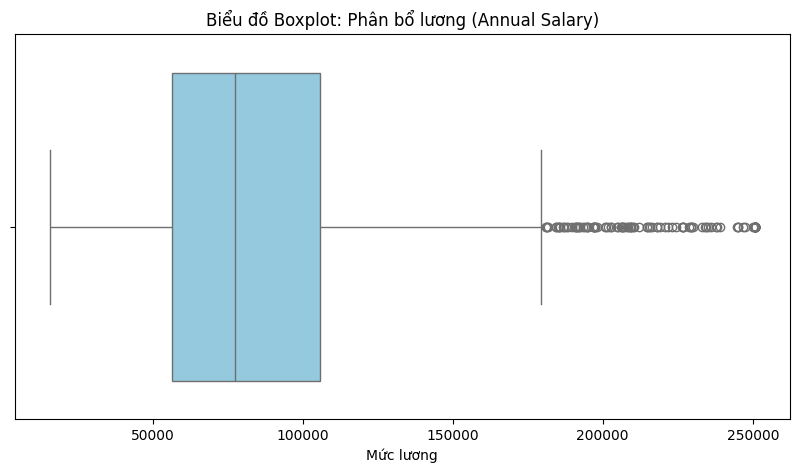


Top 5 bản ghi có mức lương cao nhất:


,job_title,annual_salary,years_of_experience_overall
616,Nurse Practitioner,250616.96,11 - 20 years
624,Cloud Engineer,250616.96,8 - 10 years
2367,Product Manager,250616.96,11 - 20 years
1294,Catering Manager,250616.96,8 - 10 years
2160,Surgeon,250616.96,5-7 years


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Hàm phát hiện Outlier bằng IQR 
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)], lower, upper

# 2. Hàm phát hiện Outlier bằng Z-Score (Dành cho phân phối chuẩn)
def detect_outliers_zscore(df, col, thresh=3):
    z = (df[col] - df[col].mean()) / df[col].std()
    return df[z.abs() > thresh]

# Thực thi kiểm tra trên cột annual_salary
outliers_iqr, low_limit, up_limit = detect_outliers_iqr(df_clean, 'annual_salary')
outliers_z = detect_outliers_zscore(df_clean, 'annual_salary')

print(f"Số lượng Outlier theo IQR: {len(outliers_iqr)}")
print(f"Số lượng Outlier theo Z-Score: {len(outliers_z)}")
# LÝ DO: Giữ lại data nhưng giới hạn giá trị tại percentile 99 (Winsorize) 
# để tránh các mức lương 'ảo' làm sai lệch mô hình.
upper_bound = df_clean['annual_salary'].quantile(0.99)
lower_bound = df_clean['annual_salary'].quantile(0.01)

df_clean['annual_salary'] = df_clean['annual_salary'].clip(lower=lower_bound, upper=upper_bound)

print(f"Đã xử lý Outlier bằng cách Clip dữ liệu trong khoảng: [{lower_bound:,.0f} - {upper_bound:,.0f}]")
# 3. Vẽ Boxplot minh họa 
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_clean['annual_salary'], color='skyblue')
plt.title('Biểu đồ Boxplot: Phân bổ lương (Annual Salary)')
plt.xlabel('Mức lương')
plt.show()

# Hiển thị thử một vài Outlier cực đại để phân tích
print("\nTop 5 bản ghi có mức lương cao nhất:")
display(df_clean[['job_title', 'annual_salary', 'years_of_experience_overall']].sort_values('annual_salary', ascending=False).head(5))

In [21]:
#pipeline chuẩn hóa chuỗi —thứtựquan trọng
df_clean['job_title'] = (df_clean['job_title']
                         .str.lower()                              # bước 1: lowercase trước
                         .str.strip()                              # bước 2: bỏ khoảng trắng
                         .str.replace(r'\s+', ' ', regex=True)   # khoảng trắng đơn
                         .str.replace(r'[^a-z0-9 ]', '', regex=True)  # bỏ ký tự đặc biệt
)
# Gom nhóm các giá trị tương đồng bằng mapping dict
title_map ={
    # Nhóm Software Engineer
    'sw engineer': 'software engineer',
    'swe': 'software engineer',
    'software dev': 'software engineer',
    # Nhóm Data Science
    'ds': 'data scientist',
    'data sci': 'data scientist'
}
df_clean['job_title'] = df_clean['job_title'].replace(title_map)

#kiêm tra kết quả sau chuẩn hóa
print("Các job_title sau khi chuẩn hóa:")
display(df_clean['job_title'].value_counts().head(10))


Các job_title sau khi chuẩn hóa:


job_title
lawyer                      26
controller                  26
assistant professor         26
transportation engineer     25
civil engineer              25
pa                          25
food  beverage manager      25
healthcare administrator    23
postdoc                     23
interior designer           23
Name: count, dtype: int64

## Lý do phải chuẩn hóa dữ liệu?
Trong thực tế, dữ liệu dạng văn bản (như job_title) thường rất hỗn loạn do người dùng nhập liệu tự do. Việc chuẩn hóa là bắt buộc vì những lý do sau:

1. Đồng nhất thực thể (Entity Resolution): Máy tính phân biệt hoa - thường và khoảng trắng. Nếu không chuẩn hóa, "Data Scientist", "data scientist" và "data scientist  " sẽ được tính là 3 nhóm khác nhau. Điều này làm sai lệch hoàn toàn các phép thống kê như count, mean hay median.

2. Gộp nhóm các giá trị tương đồng: Nhiều chức danh thực chất là một (ví dụ: SWE, Soft Eng, Software Engineer). Chuẩn hóa giúp ta đưa chúng về một định dạng duy nhất, từ đó phản ánh đúng bức tranh tổng quan của thị trường lao động.

3. Loại bỏ nhiễu (Noise Removal): Các ký tự đặc biệt (dấu phẩy, chấm than, ký tự lạ) không mang giá trị phân tích nhưng lại làm cho dữ liệu trở nên lộn xộn, gây khó khăn cho việc dùng mapping dict hoặc tìm kiếm sau này.

4. Tăng hiệu quả cho các thuật toán: Nếu dữ liệu sạch, các thư viện như fuzzywuzzy sẽ hoạt động chính xác hơn, giúp tìm ra các lỗi chính tả tinh vi mà mắt thường dễ bỏ qua.

In [22]:
from fuzzywuzzy import process

# Lấy danh sách các giá trị duy nhất trong cột
unique_titles = df_clean['job_title'].unique()

# Tìm các giá trị gần giống với "software engineer"
matches = process.extract("software engineer", unique_titles, limit=5)
print("Các giá trị gần giống software engineer:")
print(matches) 
# Kết quả trả về dạng (giá trị, điểm tương đồng)

Các giá trị gần giống software engineer:
[('software engineer', 100), ('senior software engineer', 95), ('sr software engineer', 95), ('ml engineer', 86), ('software eng', 83)]


c:\Users\Admin\Desktop\Code\DHV301\.venv\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


# 2.3 Normalization —khi nào dùng, khi nào không cần

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# 1. Khai báo cột cần xử lý
num_cols = ['annual_salary', 'additional_monetary_comp']

print("--- BẮT ĐẦU QUY TRÌNH NORMALIZATION ---")

# 2. Kiểm tra thông số TRƯỚC khi scale (để đưa vào báo cáo)
print("\n[Bước 1] Thống kê trước khi Scale:")
display(df_clean[num_cols].describe().loc[['min', 'max', 'mean']])

# 3. Thực hiện MinMaxScaler (Ép về khoảng [0, 1])
# LÝ DO: Giúp đồng nhất thang đo giữa lương và thưởng 
scaler_minmax = MinMaxScaler()
df_clean[num_cols] = scaler_minmax.fit_transform(df_clean[num_cols])
print("\n[Bước 2] Đã hoàn thành MinMaxScaler cho 'annual_salary' và 'additional_monetary_comp'.")

# 4. Thực hiện RobustScaler (Dành cho cột có nhiều Outlier)
# LÝ DO: RobustScaler dùng Median và IQR nên không bị ảnh hưởng bởi các mức lương "khủng" 
scaler_robust = RobustScaler()
df_clean['salary_robust'] = scaler_robust.fit_transform(df_clean[['annual_salary']])
print("[Bước 3] Đã tạo thêm cột 'salary_robust' bằng RobustScaler.")

# 5. Kiểm tra thông số SAU khi scale
print("\n[Bước 4] Thống kê sau khi Scale (Min-Max):")
display(df_clean[num_cols].describe().loc[['min', 'max', 'mean']])

print("\n--- KẾT QUẢ 5 DÒNG ĐẦU TIÊN ---")
display(df_clean[num_cols + ['salary_robust']].head())

--- BẮT ĐẦU QUY TRÌNH NORMALIZATION ---

[Bước 1] Thống kê trước khi Scale:


,annual_salary,additional_monetary_comp
min,0.000000,0.000000
max,1.000000,1.000000
mean,0.300205,0.056289



[Bước 2] Đã hoàn thành MinMaxScaler cho 'annual_salary' và 'additional_monetary_comp'.
[Bước 3] Đã tạo thêm cột 'salary_robust' bằng RobustScaler.

[Bước 4] Thống kê sau khi Scale (Min-Max):


,annual_salary,additional_monetary_comp
min,0.000000,0.000000
max,1.000000,1.000000
mean,0.300205,0.056289



--- KẾT QUẢ 5 DÒNG ĐẦU TIÊN ---


,annual_salary,additional_monetary_comp,salary_robust
0,0.174864,0.000000,-0.414566
1,0.548193,0.192007,1.362530
2,0.155313,0.000000,-0.507629
3,0.153018,0.360127,-0.518557
4,0.499955,0.164393,1.132914



### 1. Lý do chọn phương pháp Normalization
Việc đưa các biến số về cùng một thang đo là bước chuẩn bị quan trọng cho các thuật toán học máy. Dưới đây là các phương pháp đã được áp dụng:

* **Min-Max Scaler**: 
    * **Áp dụng cho**: `annual_salary`, `additional_monetary_comp`.
    * **Lý do**: Ép dữ liệu về khoảng **0** đến **1**. Điều này giúp các giá trị lương rất lớn không làm áp đảo các biến khác khi đưa vào mô hình. Phương pháp này phù hợp khi chúng ta không chắc chắn về phân phối của dữ liệu (không nhất thiết phải là phân phối chuẩn).
* **Standard Scaler**: 
    * **Đặc điểm**: Đưa dữ liệu về dạng có trung bình (Mean) bằng **0** và độ lệch chuẩn (Std) bằng **1**. 
    * **Lý do**: Phương pháp này phù hợp nếu dữ liệu có phân phối gần chuẩn và thường ít bị ảnh hưởng cực đoan bởi các giá trị Outlier hơn so với Min-Max trong một số mô hình như Regression hay SVM.
* **Robust Scaler (Bonus)**: 
    * **Lý do**: Được sử dụng cho cột lương vì nó sử dụng Trung vị (Median) và Khoảng cách tứ phân vị (IQR) thay vì Mean/Std. Điều này giúp thang đo bền vững hơn, không bị kéo lệch bởi các giá trị có mức lương cực cao (Outliers).



### 2. Khi nào KHÔNG cần Normalize?
Không phải mọi trường hợp đều cần thực hiện bước này. Chúng ta có thể bỏ qua khi:

* **Mô hình dựa trên cây (Tree-based)**: Như Random Forest, Decision Tree vì chúng phân tách dữ liệu dựa trên các ngưỡng (threshold), không dựa trên khoảng cách vật lý giữa các điểm nên tỷ lệ dữ liệu không ảnh hưởng đến kết quả phân tách.
* **Biến mục tiêu (Target)**: Thông thường không normalize biến dự báo để giữ nguyên đơn vị gốc (ví dụ: số tiền thực tế), giúp việc diễn giải kết quả dự báo dễ hiểu và sát thực tế hơn.
* **Biến phân loại đã Encode**: Các biến đã chuyển sang dạng **0** và **1** (như One-Hot Encoding hoặc Binary Map) vốn dĩ đã nằm trong thang đo chuẩn.

### 3. Quyết định xử lý trong bài
Dựa trên phân tích thực tế của dataset, các cột số như `annual_salary` và `additional_monetary_comp` đã được áp dụng **Min-Max Scaling** để đồng nhất thang đo về khoảng **0** đến **1**, hỗ trợ tốt nhất cho các mô hình tính toán khoảng cách và giúp các đặc trưng có vai trò ngang hàng nhau.